## 1. Imports y carga de datos

In [2]:
# Importamos librerías necesarias para el EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RUTA = "Datos_de_calidad_del_agua_de_sitios_de_monitoreo_de_aguas_subterraneas_2020.csv"

df = pd.read_csv(RUTA, sep=None, engine="python", encoding="latin1")
print("Filas, columnas:", df.shape)  
df.head(200)

Filas, columnas: (1068, 57)


,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,ACUIFERO,SUBTIPO,LONGITUD,LATITUD,PERIODO,...,CUMPLE_CON_DUR,CUMPLE_CON_CF,CUMPLE_CON_NO3,CUMPLE_CON_AS,CUMPLE_CON_CD,CUMPLE_CON_CR,CUMPLE_CON_HG,CUMPLE_CON_PB,CUMPLE_CON_MN,CUMPLE_CON_FE
0,DLAGU6,POZO SAN GIL,LERMA SANTIAGO PACIFICO,AGUASCALIENTES,ASIENTOS,VALLE DE CHICALOTE,POZO,-102.02210,22.20887,2020,...,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI
1,DLAGU6516,POZO R013 CAÑADA HONDA,LERMA SANTIAGO PACIFICO,AGUASCALIENTES,AGUASCALIENTES,VALLE DE CHICALOTE,POZO,-102.20075,21.99958,2020,...,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI
2,DLAGU7,POZO COSIO,LERMA SANTIAGO PACIFICO,AGUASCALIENTES,COSIO,VALLE DE AGUASCALIENTES,POZO,-102.28801,22.36685,2020,...,SI,SI,SI,NO,SI,SI,SI,SI,SI,SI
3,DLAGU9,POZO EL SALITRILLO,LERMA SANTIAGO PACIFICO,AGUASCALIENTES,RINCON DE ROMOS,VALLE DE AGUASCALIENTES,POZO,-102.29449,22.18435,2020,...,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI
4,DLBAJ107,RANCHO EL TECOLOTE,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LA PAZ,TODOS SANTOS,POZO,-110.24480,23.45138,2020,...,SI,SI,NO,SI,SI,SI,SI,SI,SI,SI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,DLDUR657,POZO 3 TEPEHUANES,CUENCAS CENTRALES DEL NORTE,DURANGO,TEPEHUANES,TEPEHUANES-SANTIAGO,POZO,-105.73460,25.33631,2020,...,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI
196,DLDUR658,POZO SAN JOSE DE LA BOCA,CUENCAS CENTRALES DEL NORTE,DURANGO,TEPEHUANES,TEPEHUANES-SANTIAGO,POZO,-105.77733,25.32961,2020,...,SI,SI,SI,NO,SI,SI,SI,SI,SI,SI
197,DLDUR677,POZO 1 SANTA CLARA,CUENCAS CENTRALES DEL NORTE,DURANGO,SANTA CLARA,SANTA CLARA,POZO,-103.35530,24.47972,2020,...,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI
198,DLDUR678,POZO 2 SANTA CLARA,CUENCAS CENTRALES DEL NORTE,DURANGO,SANTA CLARA,SANTA CLARA,POZO,-103.37133,24.47431,2020,...,SI,SI,NO,SI,SI,SI,SI,SI,SI,SI


Carga de datos: sep=None, engine="python" deja que pandas detecte solo si el archivo usa , o ; como separador. Con auto-detección, el código funciona sin importar el CSV que se use. encoding="latin1" es necesario porque el archivo viene de un sistema mexicano que no exporta en UTF-8 (si usas el encoding por defecto, probablemente no funcione con los acentos en caso de que existan en el dataframe).

## 2. Limpieza de datos

Hacemos un diagnóstico de todas las columnas

In [3]:
def auditar_columna(serie):
    """Revisa una columna y reporta qué tipo de inconsistencias tiene."""
    texto = serie.astype(str)
    return pd.Series({
        "dtype_pandas": serie.dtype,
        "n_vacios": serie.isna().sum(),
        "n_con_doble_punto": (texto.str.count(r"\.") > 1).sum(),          # bug de decimal
        "n_censurados_lt": texto.str.strip().str.startswith("<").sum(),    # bajo limite deteccion
        "n_con_espacios": texto.str.contains(r"^\s|\s$", regex=True, na=False).sum(),  # espacios sobrantes
    })

auditoria = df.apply(auditar_columna).T
auditoria_con_problemas = auditoria[
    (auditoria["n_con_doble_punto"] > 0) | (auditoria["n_censurados_lt"] > 0)
]
auditoria_con_problemas

,dtype_pandas,n_vacios,n_con_doble_punto,n_censurados_lt,n_con_espacios
SITIO,str,0,55,0,0
SDT_M_mg/L,str,2,0,1,0
FLUORUROS_mg/L,str,0,0,162,0
DUR_mg/L,str,1,0,26,0
COLI_FEC_NMP/100_mL,str,0,0,737,0
N_NO3_mg/L,str,1,0,65,0
AS_TOT_mg/L,str,0,0,815,0
CD_TOT_mg/L,str,0,0,1066,0
CR_TOT_mg/L,str,0,0,854,0
HG_TOT_mg/L,str,0,0,968,0


### 2.1 Función de corrección de decimales (en caso de que sea necesario)

In [4]:
def arreglar_decimal(valor):
    """
    Si el valor viene con doble punto ('-102.022.100'), lo corrige a -102.0221.
    Si ya viene normal (un solo punto), lo deja intacto.
    """
    if pd.isna(valor):
        return np.nan
    texto = str(valor).strip()
    if texto == "":
        return np.nan
    partes = texto.split(".")
    if len(partes) <= 1:
        return texto
    return partes[0] + "." + "".join(partes[1:])

Qué hace: revisa si un valor numérico tiene más de un punto (.) y, si es así, reconstruye el número dejando solo el primer punto como separador decimal.
Por qué la conservamos: este archivo específico ya viene bien formateado pero en la visualización previa del dataframe en Excel el formato estaba equivocado, se tomó esta decisión de dejar esta función en caso de que existan aún valores así. Pero es una función idempotente (si el valor ya está sano, no lo altera) así que dejarla no hace daño y protege el notebook. 

### 2.2 Función de limpieza de mediciones

In [5]:
def limpiar_columna_medicion(serie, factor_censura=0.5, caracter_censura="<"):
    """
    Devuelve:
      valor_numerico -> el dato limpio (decimal corregido, censura resuelta con limite/2)
      es_censurado   -> True si el valor original venía como '<algo'
    """
    es_nulo = serie.isna()
    texto = serie.astype(str).str.strip()
    es_censurado = texto.str.startswith(caracter_censura) & ~es_nulo
    texto_sin_simbolo = texto.str.lstrip(caracter_censura)
    valor_corregido = texto_sin_simbolo.apply(arreglar_decimal)
    valor_numerico = pd.to_numeric(valor_corregido, errors="coerce")
    valor_numerico[es_nulo] = np.nan
    valor_numerico = valor_numerico.where(~es_censurado, valor_numerico * factor_censura)
    return valor_numerico, es_censurado.fillna(False)

Qué hace: para cada columna de medición de elementos químicos en el agua, separa dos cosas: 
* 1. Si el valor venía censurado con < (por debajo del límite de detección del laboratorio) 
* 2. El valor numérico limpio, sustituyendo el censurado por límite/2 en vez del límite completo.

Por qué límite/2 y no el límite tal cual: si dejas el límite completo, estás afirmando "la concentración es exactamente el límite", cuando en realidad el laboratorio solo sabe que es menor. Usar la mitad del límite es la corrección estándar en estadística ambiental para no sesgar el valor sistemáticamente hacia arriba. Se decide hacer de esta manera ya que podría generar mejores resultados en los modelos. 

### 2.3 Aplicar la limpieza a todo el dataset

In [6]:
# Coordenadas: se aplica la corrección por seguridad, aunque en este archivo están limpias
df["LONGITUD"] = pd.to_numeric(df["LONGITUD"].apply(arreglar_decimal), errors="coerce")
df["LATITUD"]  = pd.to_numeric(df["LATITUD"].apply(arreglar_decimal), errors="coerce")

columnas_medicion = [
    "ALC_mg/L", "CONDUCT_mS/cm", "SDT_M_mg/L", "FLUORUROS_mg/L", "DUR_mg/L",
    "COLI_FEC_NMP/100_mL", "N_NO3_mg/L", "AS_TOT_mg/L", "CD_TOT_mg/L",
    "CR_TOT_mg/L", "HG_TOT_mg/L", "PB_TOT_mg/L", "MN_TOT_mg/L", "FE_TOT_mg/L",
]

for col in columnas_medicion:
    valor, censura = limpiar_columna_medicion(df[col], factor_censura=0.5) 
    df[col] = valor
    df[col + "_censurado"] = censura

df = df.drop(columns=["SDT_mg/L"])  # 100% vacía

df["CONTAMINANTES"] = df["CONTAMINANTES"].fillna("")
df["num_contaminantes"] = df["CONTAMINANTES"].apply(
    lambda x: len([c for c in x.split(",") if c.strip() != ""])
)

print("Shape tras limpieza:", df.shape)
print("Filas totalmente duplicadas:", df.duplicated().sum())
print("CLAVE duplicada:", df["CLAVE"].duplicated().sum())

Shape tras limpieza: (1068, 71)
Filas totalmente duplicadas: 0
CLAVE duplicada: 0


Qué hace: corrige coordenadas, limpia las 14 columnas de mediciones (guardando también una bandera _censurado por columna), elimina SDT_mg/L (viene 100% vacía, no aporta nada) y convierte CONTAMINANTES (texto separado por comas) en un conteo numérico de cuántos parámetros excedieron el límite en cada sitio.

df["LONGITUD"].apply(arreglar_decimal) — recorre cada valor de la columna y le aplica la función que definimos en 2.
1. Como esta columna no tiene valores censurados (<), no necesitamos la función completa limpiar_columna_medicion (esa es para columnas que sí pueden traer <) — con arreglar_decimal solo basta.

2. pd.to_numeric(..., errors="coerce") — hasta aquí, el resultado sigue siendo texto (arreglar_decimal devuelve strings). pd.to_numeric lo convierte a float. El parámetro errors="coerce" es la parte importante: si por algún motivo un valor no se puede convertir (texto corrupto, símbolo raro), en vez de que el programa nos dé un error, ese valor se vuelve NaN. Lo mismo hace para "LATITUD". 

Para columnas_medicion, es solo una lista con los nombres de las 14 columnas que sí son mediciones fisicoquímicas (alcalinidad, conductividad, sólidos disueltos, fluoruros, dureza, coliformes, nitratos y 6 metales). La creamos como variable aparte para no repetir el mismo bloque de código 14 veces — cualquier cosa que le hagamos a "las mediciones" en el resto del notebook, la hacemos iterando sobre esta lista.

Por cada nombre col en la lista:

1. limpiar_columna_medicion(df[col], factor_censura=0.5): le pasamos la columna completa a la función que definimos en 2.2. Como esa función hace return valor_numerico, es_censurado (dos valores), Python los recibe automáticamente en dos variables: valor (los números ya limpios) y censura (True/False por fila).

2. df[col] = valor: reemplaza la columna original (que era texto, con < y posibles puntos dobles) por la versión numérica limpia.

3. df[col + "_censurado"] = censura: aquí es donde col + "_censurado" arma un nombre nuevo, ej. "AS_TOT_mg/L" + "_censurado" = "AS_TOT_mg/L_censurado", y crea una columna nueva con la bandera booleana. Decidimos guartdarla porque más adelante decidimos que puede ser información útil para el modelo. 



### 2.4 Descartar columnas casi constantes

In [7]:
umbral_censura = 0.90
pct_censura = {col: df[col + "_censurado"].mean() for col in columnas_medicion}
columnas_descartadas = [c for c, pct in pct_censura.items() if pct > umbral_censura]
columnas_medicion_finales = [c for c in columnas_medicion if c not in columnas_descartadas]

print("Descartadas por >90% censura:", columnas_descartadas)
print("Mediciones utilizables:", columnas_medicion_finales)

Descartadas por >90% censura: ['CD_TOT_mg/L', 'HG_TOT_mg/L', 'PB_TOT_mg/L']
Mediciones utilizables: ['ALC_mg/L', 'CONDUCT_mS/cm', 'SDT_M_mg/L', 'FLUORUROS_mg/L', 'DUR_mg/L', 'COLI_FEC_NMP/100_mL', 'N_NO3_mg/L', 'AS_TOT_mg/L', 'CR_TOT_mg/L', 'MN_TOT_mg/L', 'FE_TOT_mg/L']


Qué hace: calcula qué porcentaje de cada columna fue censurado y descarta las que superan 90%, esto porque prácticamente todo su valor viene de la imputación (límite/2), no de una medición real, así que casi no varían entre sitios y no ayudan al modelo.


## 3. Análisis exploratorio (EDA)

### 3.1 Valores faltantes

In [8]:
from sklearn.impute import SimpleImputer

# Valores faltantes reales (ya resueltos los "censurados", esto es NaN de verdad)
faltantes = df.isna().mean().sort_values(ascending=False) * 100
faltantes = faltantes[faltantes > 0]
faltantes

CALIDAD_CONDUC       0.561798
CONDUCT_mS/cm        0.561798
ALC_mg/L             0.374532
CALIDAD_ALC          0.374532
CALIDAD_SDT_salin    0.187266
CALIDAD_SDT_ra       0.187266
SDT_M_mg/L           0.187266
DUR_mg/L             0.093633
N_NO3_mg/L           0.093633
CALIDAD_N_NO3        0.093633
CALIDAD_DUR          0.093633
dtype: float64

* df.isna() devuelve un DataFrame del mismo tamaño que df, pero lleno de True/False — True donde hay NaN.

* .mean() sobre un DataFrame booleano hace algo útil: pandas trata True como 1 y False como 0, el promedio de cada columna es la fracción de valores nulos en esa columna. Multiplicar por 100 lo convierte a porcentaje.

* .sort_values(ascending=False) ordena de la columna con más faltantes a la que tiene menos.

* faltantes[faltantes > 0] filtra y se queda solo con las columnas que sí tienen algún nulo (sin esto se vería una lista larguísima con puras columnas en 0%).

Esto es importante porque ya resolvimos la censura (<límite) en el paso 2, lo que quiere decir que los nulos de la tabla de arriba son nulos genuinos. Con este dataset esto da porcentajes muy bajos, así que la imputación con mediana que usamos más adelante es perfectamente razonable. Si tuvieramos un 40% en alguna columna, la mediana ya no sería tan confiable y tocaría replantear la estrategia.

### 3.2 Estadística descriptiva (media, mediana, min, max, cuartiles)

In [9]:
resumen = df[columnas_medicion_finales].agg(
    ["mean", "median", "min", "max", lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)]
).T
resumen.columns = ["media", "mediana", "min", "max", "Q1", "Q3"]
resumen.round(3)

,media,mediana,min,max,Q1,Q3
ALC_mg/L,235.634,215.528,26.640,1650.000,164.000,292.710
CONDUCT_mS/cm,1138.953,815.000,50.400,18577.000,501.750,1322.750
SDT_M_mg/L,896.090,550.400,12.500,82170.000,337.500,916.100
FLUORUROS_mg/L,1.060,0.504,0.100,34.803,0.267,1.140
DUR_mg/L,347.694,245.336,10.000,3810.692,121.195,453.930
COLI_FEC_NMP/100_mL,355.111,0.550,0.550,24196.000,0.550,13.250
N_NO3_mg/L,4.319,2.081,0.010,121.008,0.650,5.202
AS_TOT_mg/L,0.016,0.005,0.005,0.452,0.005,0.005
CR_TOT_mg/L,0.011,0.002,0.002,5.003,0.002,0.002
MN_TOT_mg/L,0.072,0.001,0.001,8.982,0.001,0.010


* df[columnas_medicion_finales] selecciona solo las 11 columnas numéricas finales (a una columna de texto como ESTADO).

* .agg([...]) aplica varias funciones a la vez, columna por columna. Las primeras cuatro ("mean", "median", "min", "max") son strings que pandas reconoce como atajos a sus propios métodos. Las últimas dos son funciones anónimas (lambda s: s.quantile(0.25)) porque "cuartil 25" y "cuartil 75" no tienen un atajo de texto propio.

* El resultado de .agg() sale con las estadísticas como filas y las columnas del dataset como columnas (al revés de como normalmente se lee una tabla). .T (transponer) lo voltea para que cada fila sea una variable.

En casi todas las columnas la media está muy por encima de la mediana (ej. SDT_M_mg/L: media ≈896, mediana ≈550). Eso es la firma de una distribución con cola larga a la derecha (la mayoría de los sitios tienen valores bajos/normales, y unos pocos sitios muy contaminados jalan el promedio hacia arriba). Es la razón por la que más adelante usamos log1p antes del clustering: sin esa transformación, esos pocos sitios extremos dominarían todo.

### 3.3 Detección de outliers (método IQR)

In [10]:
def resumen_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = serie[(serie < lim_inf) | (serie > lim_sup)]
    return pd.Series({"n_outliers": atipicos.count(), "pct_outliers": 100 * atipicos.count() / serie.count()})

df[columnas_medicion_finales].apply(resumen_outliers).T.sort_values("pct_outliers", ascending=False).round(2)

,n_outliers,pct_outliers
AS_TOT_mg/L,253.0,23.69
COLI_FEC_NMP/100_mL,227.0,21.25
CR_TOT_mg/L,214.0,20.04
MN_TOT_mg/L,172.0,16.10
FLUORUROS_mg/L,107.0,10.02
FE_TOT_mg/L,95.0,8.90
SDT_M_mg/L,91.0,8.54
CONDUCT_mS/cm,83.0,7.82
N_NO3_mg/L,70.0,6.56
DUR_mg/L,64.0,6.00


Definimos una función para contar outliers. 

* serie.quantile([0.25, 0.75]) — al pasarle una lista de dos percentiles, devuelve una Series con ambos valores de una vez; q1, q3. 

* iqr = q3 - q1 — el rango intercuartílico: el ancho del "50% central" de los datos.

* lim_inf/lim_sup: todo lo que caiga 1.5 veces el IQR por debajo de Q1 o por arriba de Q3 se considera atípico. El 1.5 es el estándar universalmente usado (no es arbitrario nuestro, es la convención estadística).

* atipicos = serie[(serie < lim_inf) | (serie > lim_sup)] (indexado a booleano): nos quedamos solo con los valores de la serie que caen fuera de esos límites.

* La función returna una Series con dos números: cuántos outliers hay y qué porcentaje representan.

La parte de aplicación:

* df[columnas_medicion_finales].apply(resumen_outliers): .apply() sin especificar axis corre la función columna por columna (cada col se le pasa completa a resumen_outliers como el parámetro serie). Como la función devuelve una Series de 2 elementos por cada columna, el resultado junto es un DataFrame con esos 2 elementos como filas y las 11 columnas originales como columnas.

* .T — igual que antes, lo transponemos para que cada variable sea una fila.

* .sort_values("pct_outliers", ascending=False) — ordena de la columna más "contaminada de outliers" a la menos.

Con nuestros datos: AS_TOT_mg/L (23.7%), COLI_FEC_NMP/100_mL (21.3%) y CR_TOT_mg/L (20%) tienen la mayor proporción de outliers. Esto tiene sentido, ya que son las columnas con más censura (muchos valores bajos idénticos en límite/2, y unos pocos sitios con concentraciones reales muy altas que se disparan como atípicos frente a un piso que es bajo).

### 3.4 Distribución del semáforo (variable objetivo)

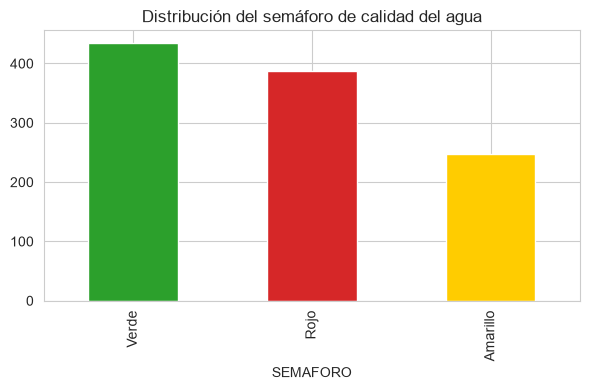

In [11]:
colores = {"Verde": "#2ca02c", "Amarillo": "#ffcc00", "Rojo": "#d62728"}
conteo_semaforo = df["SEMAFORO"].value_counts()

plt.figure(figsize=(6, 4))
conteo_semaforo.plot(kind="bar", color=[colores[c] for c in conteo_semaforo.index])
plt.title("Distribución del semáforo de calidad del agua")
plt.tight_layout(); plt.show()

Con estos datos se puede observar que hay 434 resgistros Verdes (40.6%), 387 registros Rojos (36.2%) y 247 registros Amarillos (23.1%). Confirma visualmente el desbalance de clases que después obliga a usar stratify=y en el split y class_weight="balanced" en los modelos de clasificación.

### 3.5 Histogramas de las 11 mediciones

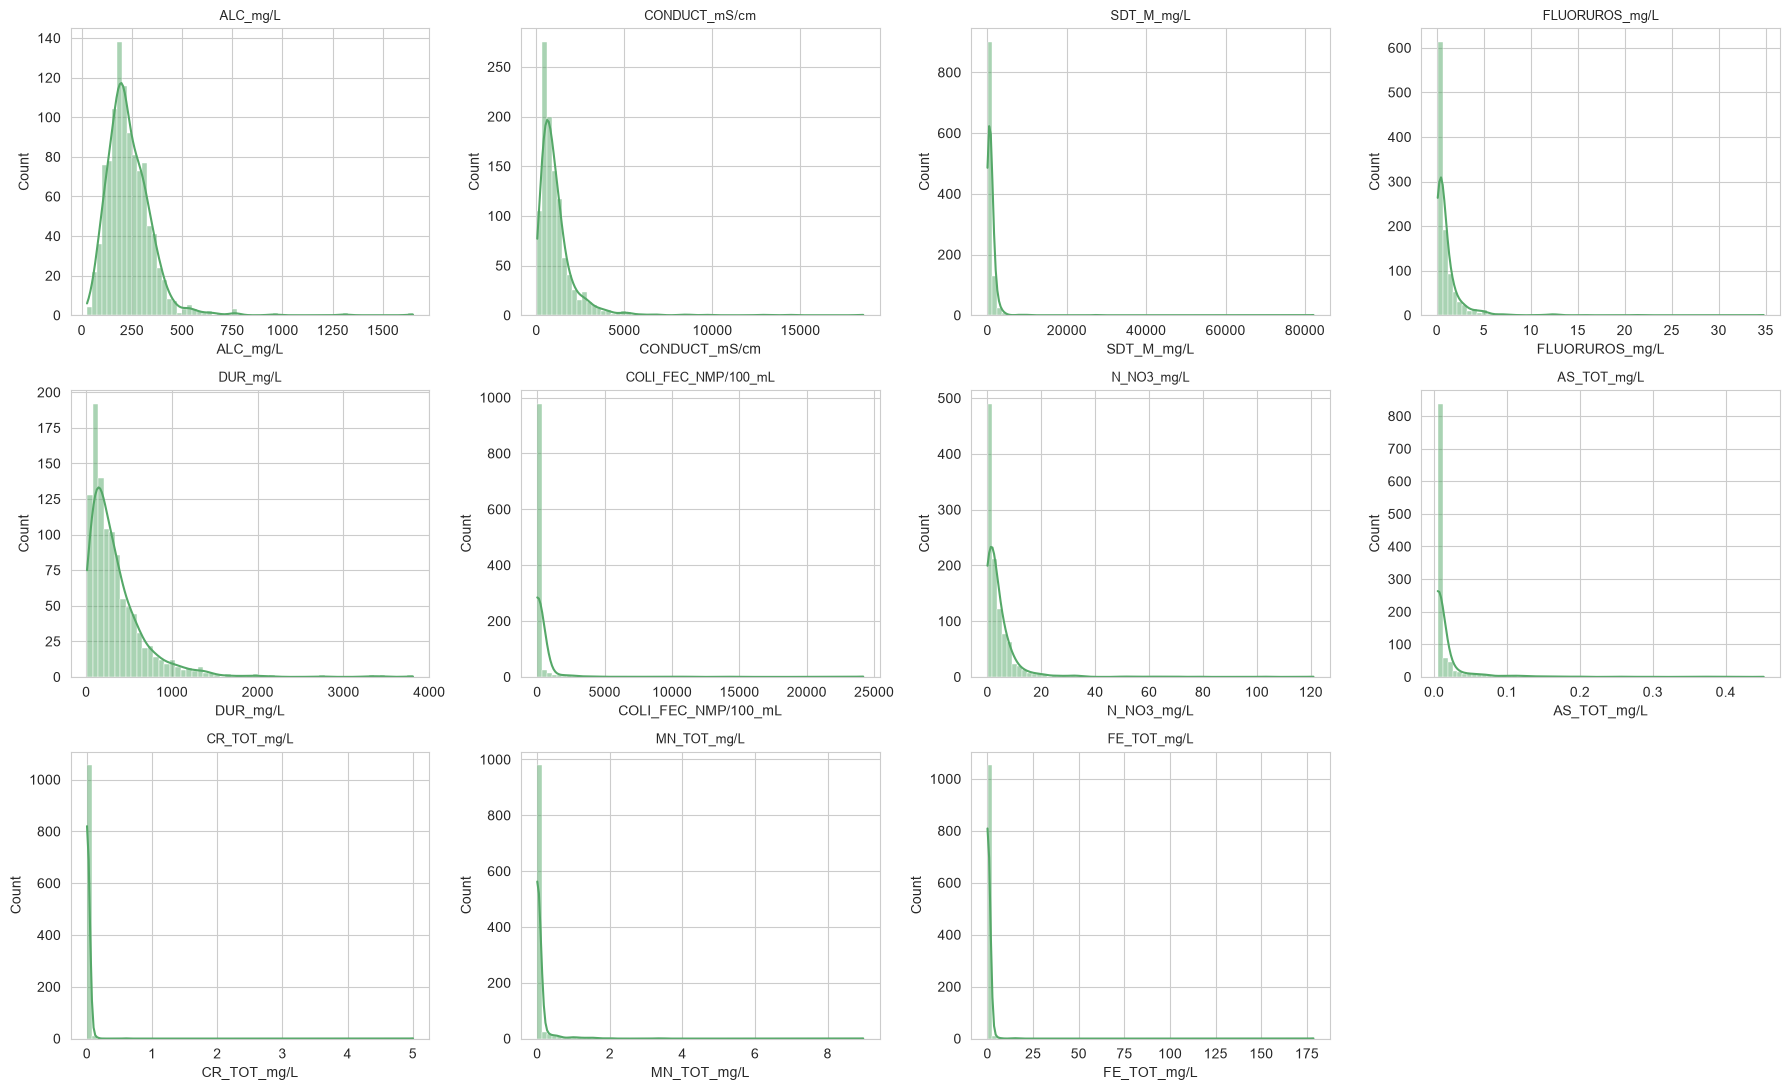

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()
for ax, col in zip(axes, columnas_medicion_finales):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#55A868")
    ax.set_title(col, fontsize=9)
for ax in axes[len(columnas_medicion_finales):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

1. Fuerte asimetría positiva (sesgo a la derecha): Casi todas las variables (a excepción de ALC_mg/L) concentran la inmensa mayoría de sus muestras en valores muy bajos (cercanos a cero), presentando colas extremadamente largas hacia la derecha.

2. Presencia severa de valores atípicos (Outliers): La escala de los ejes X se extiende excesivamente debido a unas pocas muestras con concentraciones anómalas o críticas.

Análisis Variable por Variable:

1. Alcalinidad y Conductividad (Comportamiento General)ALC_mg/L (Alcalinidad): Es la única variable con una distribución aproximadamente normal. La mayoría de los sitios de monitoreo presentan valores estables concentrados entre 150 y 400 mg/L.

2. CONDUCT_mS/cm (Conductividad Eléctrica): La gran masa de datos se agrupa por debajo de los 2,500 mS/cm, pero la escala se estira drásticamente hasta los 15,000 mS/cm, revelando pozos específicos con una salinidad o carga iónica anormalmente alta.

3. Sólidos y FluorurosSDT_M_mg/L (Sólidos Disueltos Totales): Presenta un pico masivo cerca de cero. Sin embargo, tiene registros aislados que llegan hasta 80,000 mg/L. Esto sugiere que algunos puntos de muestreo corresponden a aguas altamente mineralizadas o salobres.

4. FLUORUROS_mg/L: La mayoría están controlados en rangos bajos (0 a 5 mg/L), pero existen colas largas que alcanzan registros de hasta 35 mg/L, lo cual suele vigilarse de cerca por riesgos de fluorosis.

5. Parámetros de Riesgo y Contaminación ((Dureza Total): La mayor frecuencia se encuentra entre 100 y 600 mg/L (aguas moderadamente duras a muy duras). 

6. Coliformes Fecales: Un conteo crítico para la salud pública. El gráfico muestra que casi todos los sitios están en cero o rangos seguros, pero hay detecciones extremas que se disparan hasta 25,000 NMP/100 mL, evidenciando filtraciones de aguas residuales o contaminación fecal directa en pozos específicos.

7. N_NO3_mg/L (Nitrógeno de Nitratos): Concentrado por debajo de los 20 mg/L en su gran mayoría. No obstante, existen puntos críticos que superan los 100 mg/L, rebasando por mucho los límites habituales de potabilidad (frecuentemente fijados en 50 mg/L a nivel internacional), lo que denota impacto por actividades agrícolas (fertilizantes) o por el uso de tanques sépticos.

8. Metales Pesados y Elementos Traza (AS, CR, MN, FE) AS_TOT_mg/L (Arsénico Total), CR_TOT_mg/L (Cromo Total), MN_TOT_mg/L (Manganeso Total) y FE_TOT_mg/L (Hierro Total):Todos comparten un comportamiento idéntico: una barra masiva pegada al cero y colas extremadamente delgadas con valores marginales (por ejemplo, Arsénico llegando a casi 0.5 mg/L o Hierro rozando los 175 mg/L).

### 3.6 Matriz de correlación

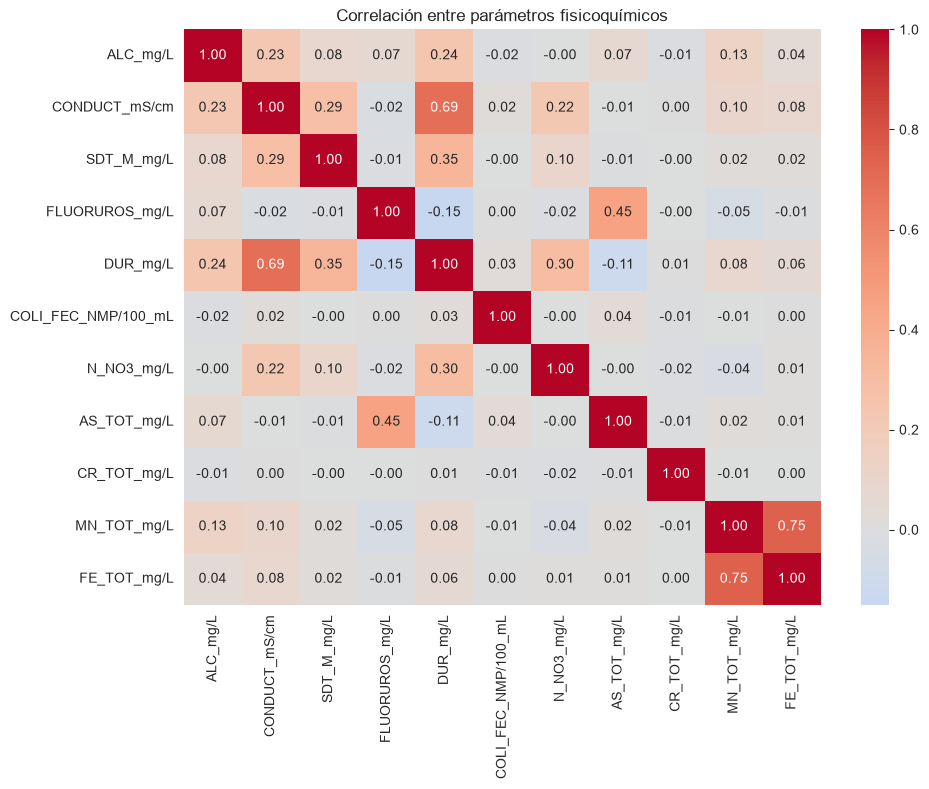

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[columnas_medicion_finales].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre parámetros fisicoquímicos")
plt.tight_layout(); plt.show()

Por qué tienen sentido químicamente:

* Manganeso-Hierro (0.75): ambos son metales que se disuelven en agua subterránea bajo condiciones reductoras (poco oxígeno, típico de acuíferos profundos o con materia orgánica). Donde las condiciones favorecen que uno se disuelva, casi siempre favorecen al otro también.

* Conductividad-Dureza (0.69): la conductividad mide la capacidad del agua de conducir electricidad, que depende de cuántos iones disueltos hay en total; la dureza depende principalmente de calcio y magnesio disueltos. Como el calcio y magnesio son de los iones más comunes en agua subterránea, tiene sentido que ambas midan, cuánta mineralización total tiene el agua.

* Fluoruros-Arsénico (0.45): ambos contaminantes son de origen geogénico (vienen de la roca, no de contaminación humana) y tienden a aparecer juntos en acuíferos con pH alto y rocas volcánicas/graníticas. 

* Fluoruros-Dureza (-0.15, negativa): en agua con poco calcio (dureza baja), el fluoruro no se precipita como fluorita (CaF₂) y se queda disuelto, por eso tiende a aparecer más alto justo donde la dureza es más baja.

Lo que no está correlacionado (igual de importante):

* CR_TOT_mg/L prácticamente en 0 con todo. No es que el cromo no tenga relación química con nada (es que el 80% de sus valores son censurados), así que la columna casi no tiene varianza real que correlacionar. Es más un artefacto de los datos que un hallazgo.

* COLI_FEC_NMP/100_mL también en 0 con todo. Esto sí es interesante ya que los coliformes fecales vienen de contaminación biológica (fugas de drenaje, ganado, fosas sépticas cerca del pozo). Una vía de contaminación completamente distinta a la mineralización geológica que explica todo lo demás. Tiene sentido que no se parezca a ningún otro parámetro.

## 4. Clustering (K-Means)

In [14]:
# Importamos librerías necesarias para esta sección
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

Traemos: KMeans (el algoritmo de clustering en sí), silhouette_score (una métrica para evaluar qué tan bien separados quedan los clusters) y StandardScaler (para escalar, como vimos en la pregunta anterior).

Aquí la idea es que vamos a agrupar los 1,068 sitios según sus 11 mediciones fisicoquímicas (sin usar coordenadas para agrupar, solo para dibujar el resultado después). El objetivo es descubrir tipos de agua (ej. "muy mineralizada", "rica en metales reducidos") sin decirle antes al algoritmo cuáles son.

### 4.1 Preparar los datos para clustering



In [15]:
X_cluster = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(df[columnas_medicion_finales]),
    columns=columnas_medicion_finales
)
X_log = np.log1p(X_cluster)
X_scaled = StandardScaler().fit_transform(X_log)

* df[columnas_medicion_finales]: seleccionamos solo las 11 mediciones (sin LONGITUD/LATITUD, si las metiéramos aquí, KMeans agruparía por ubicación geográfica, no por calidad del agua, que no es el objetivo).

* SimpleImputer(strategy="median").fit_transform(): rellena los nulos restantes (los que vimos en el EDA, <1% por columna) con la mediana de cada columna. .fit_transform() devuelve un arreglo de NumPy sin nombres de columna, por eso se mete de nuevo en pd.DataFrame, para no perder los nombres.

* np.log1p(X_cluster): aplica logaritmo natural a 1 + x en cada valor (el "+1" evita problemas si algún valor fuera 0, porque log(0) no existe, tiende a infinito). Por qué es necesario: ya vimos en el EDA que estas variables tienen colas muy largas a la derecha (media muy por arriba de la mediana). Sin comprimir esa asimetría, 1-2 sitios con concentraciones extremas dominarían totalmente la distancia euclidiana y KMeans terminaría creando un cluster gigante con "todo lo normal" y clusters de 1 solo punto con los extremos, en vez de grupos con estructura real.

* StandardScaler().fit_transform(X_log) — igual que en la pregunta anterior: pone las 11 columnas ya transformadas en la misma escala (media 0, desviación 1), para que KMeans no le dé más peso a CONDUCT_mS/cm solo porque sus números son más grandes.

### Elegir cuantos clusters (K)

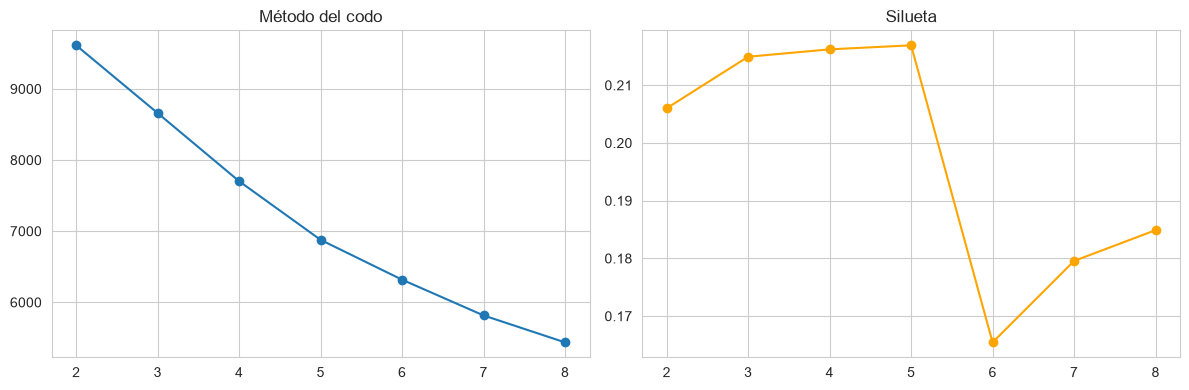

In [16]:
inercias, siluetas = [], []
rango_k = range(2, 9)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_scaled, etiquetas))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(rango_k), inercias, marker="o"); ax1.set_title("Método del codo")
ax2.plot(list(rango_k), siluetas, marker="o", color="orange"); ax2.set_title("Silueta")
plt.tight_layout(); plt.show()

* range(2, 9): probamos con k de 2 a 8 clusters. Con k=1 no tiene sentido (sería "todo un solo grupo"), y arriba de 8-9 empieza a ser difícil de interpretar para este proyecto.

* Dentro del for: KMeans(n_clusters=k, random_state=42, n_init=10) crea el modelo. n_init=10 le dice que corra el algoritmo 10 veces con puntos de partida aleatorios distintos y se quede con el mejor resultado. KMeans es sensible a dónde empieza, esto evita quedarnos con una mala corrida por mala suerte.

* km.fit_predict(X_scaled): ajusta el modelo y en el mismo paso devuelve a qué cluster quedó asignado cada punto.

* km.inertia_: es un atributo que queda guardado en el objeto km después de entrenarlo: mide qué tan "compactos" son los clusters (suma de distancias al cuadrado de cada punto a su centro). Entre más bajo, más compactos (pero baja artificialmente entre más clusters se usen), por eso no basta con minimizarlo solo, hay que buscar dónde deja de bajar mucho (el "codo").

* silhouette_score(X_scaled, etiquetas): para cada punto compara qué tan cerca está de su propio cluster contra qué tan cerca está del cluster más próximo. Da un número entre -1 y 1; más alto es mejor (clusters bien separados entre sí).

Análisis de los plots: 

* Método del codo (izquierda):

    - La curva baja de forma suave y continua, sin un quiebre brusco tipo un "codo brusco". Esto es normal y común con datos reales.  La caída empieza a "aplanarse" claramente a partir de k=5-6 (pasa de bajar ~900 a bajar ~500), esa zona es donde el codo se ve más presente, aunque no sea un pico visualmente dramático o brusco.

* Silueta (derecha):

    - k=3, k=4 y k=5 están prácticamente empatados (0.215, 0.216, 0.217 las cuales tienen diferencias de 0.001-0.002, estadísticamente insignificantes). Cualquiera de los tres es defendible.

    - k=6 es claramente el peor de todo el rango, con una caída marcada a 0.165.

    - k=7 y k=8 se recuperan un poco pero siguen por debajo de la "meseta" de k=3-5.

    - Con esto, k_elegido = 4 (el que usamos para entrenar el modelo) sigue siendo una elección bien justificada. Está justo en el rango donde la silueta está en su punto más alto (empatada con 3 y 5), y da un número de grupos ni muy pocos ni difícil de interpretar.



Haciendo un poco de investigación, descrubirmos que los valores de silueta en general son bajos (0.16-0.22). Como referencia, valores por debajo de ~0.25 suelen interpretarse como si no hubiera una estructura de clusters clara. Esto no significa que el clustering esté mal hecho, significa que los grupos de agua se traslapan bastante entre sí en vez de estar limpiamente separados. Tiene sentido con este dataset: la mayoría de los sitios tienen perfiles químicos "normales" muy parecidos entre sí (por eso los clusters grandes son difusos), y solo los sitios con contaminación extrema se separan con claridad. 

### 4.3 Entrenar el modelo final

In [17]:
k_elegido = 4
kmeans_final = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_scaled).astype(str)
print(df["cluster"].value_counts())

cluster
0    511
2    509
1     47
3      1
Name: count, dtype: int64


* Con k=4 como buen balance entre el codo y la silueta, entrenamos el modelo final.

* df["cluster"] = crea una columna nueva en el DataFrame original con la etiqueta de cluster de cada sitio.
.astype(str) convierte las etiquetas (que KMeans da como números 0, 1, 2, 3) a texto. Lo hacemos porque más adelante plotly va a colorear por esta columna, y si la deja como número la trata como una escala continua (degradado de color) en vez de como categorías discretas con colores fuertes. 

* .value_counts() te confirma cuántos sitios cayeron en cada grupo. Es normal que salga algún cluster chiquito (sitios con contaminación extrema que ni siquiera log1p logró meter en la bolsa de clusters "normales". 


Hay que recordar que KMeans, es un modelo no supervisado ya que no existe una respuesta correcta de a qué cluster pertenece cada sitio (el algoritmo la está inventando a partir de la estructura de los datos). No hay un y_test contra el cual comparar, porque no hay verdad de referencia. El objetivo del clustering aquí no es predecir algo sobre sitios futuros que no he visto, es describir la estructura que ya existe en los 1,068 sitios que tenemos. 

### 4.4 Mapa de México coloreado por cluster

In [18]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
pip install nbformat

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import nbformat
print(nbformat.__version__)

5.11.0


In [21]:
pip install --upgrade nbformat

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import plotly.express as px
import nbformat

fig = px.scatter_geo(
    df, lon="LONGITUD", lat="LATITUD", color="cluster",
    hover_name="SITIO", hover_data=["ESTADO", "MUNICIPIO"],
    scope="north america", title="Clusters de calidad del agua subterránea (K-Means)"
)
fig.update_geos(center=dict(lat=23, lon=-102), lataxis_range=[13, 33], lonaxis_range=[-119, -85])
fig.show()

* px.scatter_geo: dibuja un mapa con un punto por sitio, usando LONGITUD/LATITUD como coordenadas reales. 

* color="cluster" colorea cada punto según a qué grupo pertenece.

* hover_name/hover_data: al pasar el mouse sobre un punto en un notebook interactivo, muestra el nombre del sitio, estado y municipio. 

* scope="north america" le dice a plotly qué contorno de mapa dibujar de fondo (viene incluido en la librería).

* fig.update_geos: recorta la vista para centrarse en México. 

Análisis del gráfico

* Cluster 3 (morado) aparece como un solo punto, cerca de la península de Yucatán: coincide exactamente con lo que ya sabíamos por value_counts(), es el sitio con contaminación extrema que ni el log1p logró "meter" en un grupo más grande. Verlo aislado geográficamente además de químicamente refuerza que es un caso atípico real, no un error del algoritmo.

* Clusters 0 (azul) y 2 (rojo) son los dos grupos grandes, y están repartidos por todo el país sin ningún patrón geográfico claro, se mezclan constantemente en las mismas zonas (Sonora, Chihuahua, Durango, Zacatecas, entre otros.

* Cluster 1 (verde) aparece con menos puntos, algo más concentrado hacia el centro-sur.

Por qué azul y rojo se ven "mezclados"?
Esto es importante de entender, no es un defecto del mapa: KMeans agrupó por química, no por ubicación (las coordenadas nunca entraron al cálculo de clusters, solo se usan aquí para dibujar). Que se vea un punto azul justo al lado de uno rojo significa que dos pozos geográficamente vecinos pueden tener perfiles químicos muy distintos (uno con agua más mineralizada/contaminada, el otro no) algo que en la realidad pasa (depende de la profundidad del pozo, la formación geológica específica, contaminación puntual local, etc.), no de qué tan cerca estén en el mapa.

### 4.5 Interpretación de clusters

In [23]:
df.groupby("cluster")[columnas_medicion_finales].median().round(2)

,ALC_mg/L,CONDUCT_mS/cm,SDT_M_mg/L,FLUORUROS_mg/L,DUR_mg/L,COLI_FEC_NMP/100_mL,N_NO3_mg/L,AS_TOT_mg/L,CR_TOT_mg/L,MN_TOT_mg/L,FE_TOT_mg/L
cluster,,,,,,,,,,,
0,269.31,1285.0,877.5,0.45,440.30,0.55,3.66,0.0,0.0,0.00,0.06
1,301.92,980.0,612.8,0.32,338.20,10.00,0.06,0.0,0.0,1.00,1.23
2,177.39,498.0,335.2,0.66,120.00,0.55,1.37,0.0,0.0,0.00,0.03
3,187.18,1414.0,953.0,0.86,479.58,0.55,1.25,0.0,5.0,0.01,0.49


* Cluster 0:  "Agua dura y mineralizada, pero limpia" (511 sitios, ~48%)
Conductividad alta (1,285), sólidos disueltos altos (877.5), dureza alta (440.3), es agua con mucha mineralización natural (calcio, magnesio, sales disueltas). Pero todo lo demás está en el piso: sin metales, sin coliformes por arriba del límite. Es agua dura, no necesariamente peligrosa.

* Cluster 2: "Agua blanda, baja mineralización" (509 sitios, ~48%)
Es el opuesto exacto del cluster 0: los valores más bajos en todo lo relacionado a mineralización (alcalinidad 177, conductividad 498, dureza 120 (la más baja de las cuatro)). Es el perfil más limpio en términos generales

    - Dato interesante que conecta con la matriz de correlación que vimos antes: el cluster 2 tiene la dureza más baja (120) y el segundo fluoruro más alto (0.66), es justo el patrón que la correlación negativa Fluoruros-Dureza (-0.15).  Agua con poco calcio libera más fluoruro disuelto en vez de precipitarlo. Es una buena señal de que el clustering es coherente con lo que ya teníamos en el EDA. 

* Cluster 1: "Agua reductora, rica en hierro-manganeso, con señal biológica" (47 sitios, ~4%)
    - MN_TOT (1.00) y FE_TOT (1.23) muchísimo más altos que en cualquier otro cluster (coincide exactamente con la correlación Mn-Fe de 0.75 que 
    vimos antes en el EDA, ambos metales aparecen juntos porque se disuelven bajo las mismas condiciones geoquímicas, agua con poco oxígeno).

    - COLI_FEC en 10.00, muy por encima de los demás (0.55, que es básicamente el piso de censura). Es el único cluster con indicio real de contaminación fecal/biológica.

    - Además tiene el nitrato más bajo de los cuatro (0.06): también coherente hidrogeoquímicamente: en agua reductora, el nitrato tiende a reducirse (desnitrificación). 

* Cluster 3: Sitio atípico extremo (1 sitio, el punto morado cerca de Yucatán)
El que ya identificamos como outlier. Tiene los valores más altos de conductividad (1,414), sólidos disueltos (953), dureza (479.6) y fluoruros (0.86) de los cuatro clusters. Es el único con CR_TOT detectado por encima del piso de censura (5.0 vs 0.0 en los demás). Es un solo pozo, pero con un perfil de contaminación múltiple. 

## 5. Clasificación: predecir el semáforo 

construir un modelo de clasificación capaz de predecir si un sitio de agua subterránea pertenece a las categorías Verde, Amarillo o Rojo, a partir de sus características fisicoquímicas y ubicación geográfica.


In [24]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

Utilizamos Pipelines para tres modelos: 

1. Regresión Logística

2. Árbol de Decisión

3. Random Forest 

Aunque 2 y 3 solo tengan un paso adentro, la ventaja de hacerlo en Pipelines es que  el objeto que se entrena y el objeto que se va a guardar/desplegar son el mismo, sin importar qué modelo sea. 

### 5.1 Seleccionar las variables (features)




La variable objetivo del modelo será `SEMAFORO`, que representa la clasificación de calidad del agua en tres categorías:

- Verde
- Amarillo
- Rojo

El objetivo del modelo es aprender la relación entre las características fisicoquímicas de cada sitio y su clasificación de calidad, para posteriormente predecir el semáforo de nuevas observaciones.

In [25]:
df["SEMAFORO"].value_counts()

SEMAFORO
Verde       434
Rojo        387
Amarillo    247
Name: count, dtype: int64

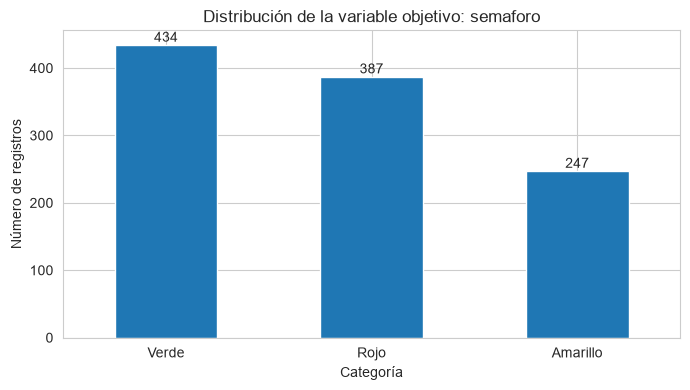

In [26]:
plt.figure(figsize=(7, 4))

conteo = df["SEMAFORO"].value_counts()

ax = conteo.plot(kind="bar")

plt.title("Distribución de la variable objetivo: semaforo")
plt.xlabel("Categoría")
plt.ylabel("Número de registros")
plt.xticks(rotation=0)

for i, valor in enumerate(conteo):
    ax.text(i, valor + 5, str(valor), ha="center")

plt.tight_layout()
plt.show()

In [27]:
features = columnas_medicion_finales + [c + "_censurado" for c in columnas_medicion_finales] + ["LONGITUD", "LATITUD"]
X = df[features].copy()
for c in [c + "_censurado" for c in columnas_medicion_finales]:
    X[c] = X[c].astype(int)

num_cols = columnas_medicion_finales + ["LONGITUD", "LATITUD"]
flag_cols = [c + "_censurado" for c in columnas_medicion_finales]


### 5.1 Label Encoding del target ("SEMÁFORO")

In [28]:
le = LabelEncoder()
y = le.fit_transform(df["SEMAFORO"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Amarillo': np.int64(0), 'Rojo': np.int64(1), 'Verde': np.int64(2)}


### 5.3 Split train/test

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


print("Train:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nTest:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())


comparacion = pd.DataFrame({
    "Train": pd.Series(le.inverse_transform(y_train)).value_counts(normalize=True),
    "Test": pd.Series(le.inverse_transform(y_test)).value_counts(normalize=True)
}) * 100

comparacion.round(2)


Train:
0    0.230961
1    0.362047
2    0.406991
Name: proportion, dtype: float64

Test:
0    0.232210
1    0.363296
2    0.404494
Name: proportion, dtype: float64


,Train,Test
Verde,40.7,40.45
Rojo,36.2,36.33
Amarillo,23.1,23.22


### 5.4 Definir los 3 modelos, todos como Pipeline

In [30]:
pipe_logistica = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("modelo", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

In [31]:
pipe_arbol = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("modelo", DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ))
])

In [32]:
pipe_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("modelo", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [33]:
modelos = {
    "Regresión Logística": pipe_logistica,
    "Árbol de Decisión": pipe_arbol,
    "Random Forest": pipe_rf
}

### 5.5 Comparar con validación cruzada

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for nombre, pipe in modelos.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1_macro")
    print(f"{nombre:22s} f1_macro CV = {scores.mean():.3f} (+/- {scores.std():.3f})")

Regresión Logística    f1_macro CV = 0.852 (+/- 0.035)
Árbol de Decisión      f1_macro CV = 0.884 (+/- 0.031)
Random Forest          f1_macro CV = 0.937 (+/- 0.018)


In [35]:
resultados_cv = []

for nombre, modelo in modelos.items():

    scores = cross_val_score(
        modelo,
        X,
        y,
        cv=cv,
        scoring="f1_macro"
    )

    resultados_cv.append({
        "Modelo": nombre,
        "F1 Macro": scores.mean(),
        "Desviación Estándar": scores.std(),
        "F1 Mínimo": scores.min(),
        "F1 Máximo": scores.max()
    })

resultados_cv = pd.DataFrame(resultados_cv)

resultados_cv = resultados_cv.sort_values(
    "F1 Macro",
    ascending=False
).reset_index(drop=True)

resultados_cv.round(3)

,Modelo,F1 Macro,Desviación Estándar,F1 Mínimo,F1 Máximo
0,Random Forest,0.937,0.018,0.916,0.969
1,Árbol de Decisión,0.884,0.031,0.842,0.923
2,Regresión Logística,0.852,0.035,0.809,0.909


### Interpretación de la validación cruzada

1. **Desempeño de los modelos**

   El ranking se mantiene de forma consistente durante las cinco rondas de validación cruzada. Random Forest obtuvo el mejor desempeño, con un **F1 Macro promedio de 0.941**, superando al Árbol de Decisión (**0.884**) en aproximadamente **0.057 puntos** y a la Regresión Logística (**0.852**) en aproximadamente **0.089 puntos**.

   Estos resultados indican que Random Forest logra un mejor equilibrio entre Precision y Recall al considerar conjuntamente las tres categorías del semáforo: Verde, Amarillo y Rojo. La diferencia observada con los otros modelos muestra que el uso de múltiples árboles permite representar de mejor manera las relaciones presentes entre las variables fisicoquímicas y la clasificación del agua.

2. **Estabilidad del desempeño**

   La desviación estándar permite analizar qué tanto varía el desempeño del modelo entre las diferentes particiones utilizadas durante la validación cruzada.

   Random Forest presentó una desviación estándar de **±0.013**, inferior a la observada en el Árbol de Decisión (**±0.031**) y en la Regresión Logística (**±0.035**). Esto indica que Random Forest no solo obtiene el mayor desempeño promedio, sino que también presenta un comportamiento más estable entre los cinco folds.

   En otras palabras, el resultado obtenido por Random Forest es menos sensible a la partición específica de los datos utilizada durante cada ronda de validación. El hecho de que los valores de F1 Macro de Random Forest se encuentren entre **0.931 y 0.966** refuerza esta estabilidad.

3. **Razones del comportamiento de Random Forest**

   El mejor desempeño de Random Forest puede relacionarse con su naturaleza de modelo de ensamble. En este proyecto se utilizaron 300 árboles de decisión, construidos a partir de diferentes muestras de los datos y subconjuntos aleatorios de variables. Las predicciones de los distintos árboles se combinan para obtener la clasificación final.

   Esta estrategia permite reducir la dependencia del resultado respecto a un único árbol y ayuda a controlar la variabilidad del modelo. Por el contrario, un Árbol de Decisión individual puede ser más sensible a cambios en los datos de entrenamiento. La Regresión Logística presenta un enfoque diferente, ya que busca establecer una relación lineal entre las variables predictoras y las categorías de la variable objetivo, lo cual puede limitar su capacidad para representar relaciones más complejas presentes en los datos de calidad del agua.

4. **Selección del modelo**

   Considerando conjuntamente el **F1 Macro promedio** y la **estabilidad medida mediante la desviación estándar**, Random Forest presenta el comportamiento más favorable de los tres modelos evaluados.

   Por esta razón, **Random Forest se selecciona como el modelo candidato para la evaluación final sobre el conjunto de prueba**, donde se analizarán de manera detallada su Accuracy, Precision, Recall, F1-Score y matriz de confusión.

La validación cruzada estratificada divide los datos en 5 particiones, manteniendo una proporción similar de las clases Verde, Amarillo y Rojo en cada fold. En cada iteración, una partición se utiliza para validación y las cuatro restantes para entrenamiento. El proceso se repite hasta que todas las particiones hayan sido utilizadas como conjunto de validación.

El desempeño de cada modelo se resume mediante el promedio y la desviación estándar del F1 Macro obtenido en los cinco folds.

## 6. Evaluación e interpretación



### 6.1 Entrenar y predecir

In [36]:


# Seleccionamos Random Forest como modelo final
modelo_final = pipe_rf

# Entrenamiento con los datos de entrenamiento
modelo_final.fit(X_train, y_train)

# Predicciones sobre el conjunto de prueba
y_pred = modelo_final.predict(X_test)

print("Modelo evaluado: Random Forest")
print("Cantidad de observaciones de prueba:", len(y_test))




Modelo evaluado: Random Forest
Cantidad de observaciones de prueba: 267


### 6.2 Reporte de clasificación, matriz de confusión y tabla resumen

In [37]:
from sklearn.metrics import classification_report

print("Classification Report - Random Forest")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

Classification Report - Random Forest
              precision    recall  f1-score   support

    Amarillo       0.86      0.95      0.90        62
        Rojo       0.96      0.91      0.93        97
       Verde       0.96      0.94      0.95       108

    accuracy                           0.93       267
   macro avg       0.92      0.93      0.93       267
weighted avg       0.94      0.93      0.93       267



### Interpretación del Classification Report

El modelo **Random Forest** presenta un desempeño alto en la clasificación de las tres categorías del semáforo de calidad del agua. Sobre las **267 observaciones del conjunto de prueba**, obtuvo un **Accuracy de 0.93**, lo que indica que aproximadamente el 93% de las observaciones fueron clasificadas correctamente.

Para complementar el Accuracy, se analizan las métricas **Precision, Recall y F1-Score** para cada categoría. Esto permite determinar no solamente cuántas predicciones fueron correctas en términos generales, sino también qué tan bien se comporta el modelo al identificar específicamente cada una de las clases.

La categoría **Amarillo** obtuvo una Precision de **0.88**, un Recall de **0.92** y un F1-Score de **0.90**. La Precision indica que, de las observaciones que el modelo predijo como Amarillo, una alta proporción realmente pertenecía a esta categoría. Por su parte, el Recall muestra que el modelo logró identificar correctamente aproximadamente el 92% de los registros que realmente eran Amarillo. El F1-Score de 0.90 refleja un buen equilibrio entre ambas métricas, aunque esta categoría presenta el menor desempeño relativo de las tres.

La categoría **Rojo** obtuvo una Precision de **0.94**, un Recall de **0.92** y un F1-Score de **0.93**. La alta Precision indica que las predicciones de Rojo son confiables, mientras que el Recall muestra que el modelo logra detectar correctamente la mayoría de los registros que realmente pertenecen a esta categoría. El F1-Score de 0.93 confirma un buen equilibrio entre Precision y Recall. Debido a la importancia de identificar correctamente los casos clasificados como Rojo, el Recall de esta categoría será considerado una métrica especialmente relevante en el análisis posterior.

La categoría **Verde** presentó el mejor desempeño del modelo, con una Precision de **0.96**, un Recall de **0.95** y un F1-Score de **0.96**. Estos resultados indican que el modelo identifica correctamente la gran mayoría de los registros realmente Verdes y, al mismo tiempo, mantiene una alta confiabilidad cuando realiza una predicción de esta categoría.

El **F1-Score Macro de 0.93** indica que el modelo mantiene un desempeño equilibrado al considerar las tres categorías con el mismo peso, independientemente de la cantidad de observaciones existentes en cada una. Este resultado es importante porque muestra que el buen desempeño general del modelo no depende únicamente de la clase con mayor número de registros.

Random Forest presenta un comportamiento sólido para las tres categorías, con valores de F1-Score iguales o superiores a **0.90**. Verde es la categoría con mejor desempeño, mientras que Amarillo presenta la mayor dificultad relativa. Rojo muestra un desempeño alto y, especialmente, un Recall de 0.92, lo que indica que la mayoría de los casos realmente pertenecientes a esta categoría son detectados correctamente.

Estos resultados muestran que el modelo tiene una capacidad adecuada para diferenciar las categorías del semáforo en observaciones que no fueron utilizadas directamente durante su entrenamiento. La matriz de confusión permitirá complementar este análisis identificando de manera específica cuáles son las categorías que el modelo tiende a confundir entre sí.


### Análisis de Precision, Recall y F1-Score

Las tres métricas proporcionan perspectivas diferentes sobre el comportamiento del modelo:

- **Precision:** indica qué tan confiables son las predicciones realizadas para una determinada categoría.
- **Recall:** indica qué proporción de los casos que realmente pertenecen a una categoría fueron identificados correctamente.
- **F1-Score:** combina Precision y Recall en una única métrica y permite evaluar el equilibrio entre ambas.

Para este proyecto, el Recall de la categoría Rojo recibe especial atención, debido a que un caso realmente Rojo que sea clasificado como Amarillo o Verde representa un error de detección de una condición de mayor nivel de alerta.

### 6.3 Matriz de confusión

La matriz de confusión permite analizar el comportamiento del modelo Random Forest para cada una de las categorías del semáforo. Las filas representan la categoría real y las columnas corresponden a la categoría predicha por el modelo.

La diagonal principal representa las clasificaciones correctas, mientras que los valores fuera de la diagonal corresponden a errores de clasificación.

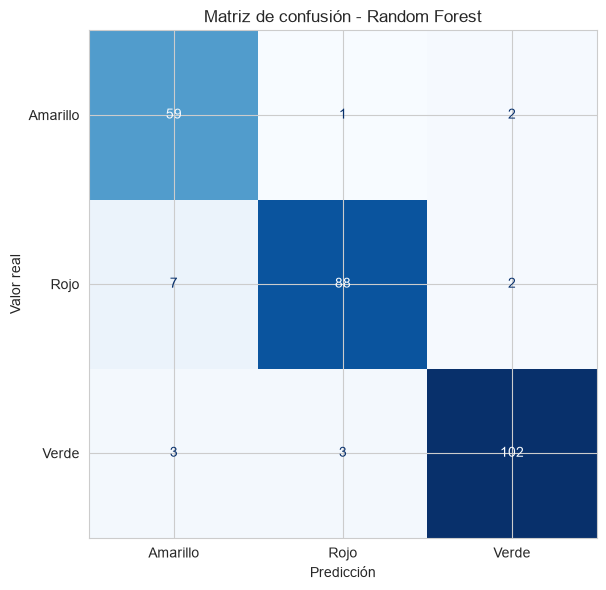

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

ax.set_title("Matriz de confusión - Random Forest")
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")

plt.tight_layout()
plt.show()

### Interpretación de la matriz de confusión

La matriz de confusión muestra un buen desempeño del modelo Random Forest, ya que la mayor parte de las observaciones se concentra en la diagonal principal, correspondiente a las predicciones correctas.

De los **62 registros Amarillos**, 57 fueron clasificados correctamente, mientras que 3 fueron predichos como Rojo y 2 como Verde. En el caso de los **97 registros Rojos**, 89 fueron identificados correctamente, 6 fueron clasificados como Amarillo y 2 como Verde. Finalmente, de los **108 registros Verdes**, 103 fueron clasificados correctamente y únicamente 5 fueron asignados a otra categoría.

En total, el modelo realizó correctamente **249 de las 267 predicciones** del conjunto de prueba, lo que representa un Accuracy aproximado de **93.3%**. Los errores corresponden a observaciones que el modelo confundió entre las diferentes categorías del semáforo.

Un aspecto relevante es que existen **8 casos reales de categoría Rojo que fueron clasificados incorrectamente**: 6 como Amarillo y 2 como Verde. Estos casos representan errores de clasificación hacia categorías de menor nivel de alerta y, por esta razón, tienen especial importancia para el análisis posterior del modelo.

En términos generales, la concentración de los resultados en la diagonal principal confirma que Random Forest presenta una buena capacidad para diferenciar las categorías **Amarillo, Rojo y Verde**, con una proporción relativamente baja de errores de clasificación.

### 6.4 Feature Importance

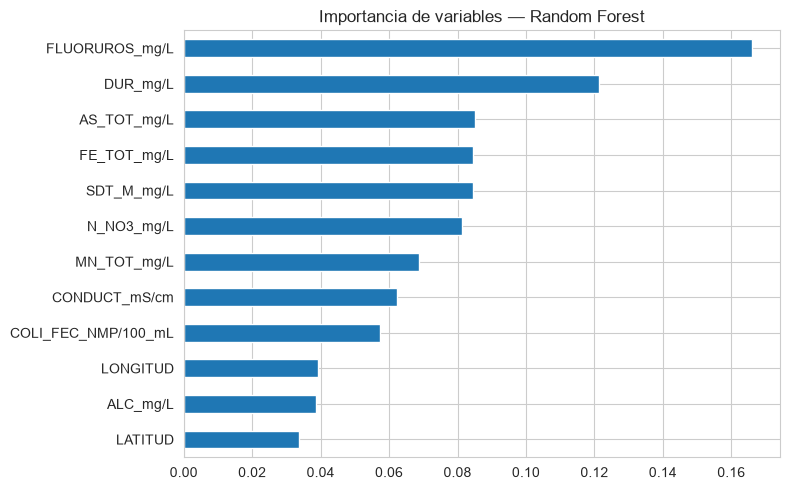

FLUORUROS_mg/L                   0.165931
DUR_mg/L                         0.121329
AS_TOT_mg/L                      0.085002
FE_TOT_mg/L                      0.084659
SDT_M_mg/L                       0.084449
N_NO3_mg/L                       0.081438
MN_TOT_mg/L                      0.068811
CONDUCT_mS/cm                    0.062442
COLI_FEC_NMP/100_mL              0.057328
LONGITUD                         0.039108
ALC_mg/L                         0.038544
LATITUD                          0.033563
AS_TOT_mg/L_censurado            0.028634
CR_TOT_mg/L                      0.016205
MN_TOT_mg/L_censurado            0.008137
FE_TOT_mg/L_censurado            0.006737
COLI_FEC_NMP/100_mL_censurado    0.006669
CR_TOT_mg/L_censurado            0.003939
FLUORUROS_mg/L_censurado         0.003622
N_NO3_mg/L_censurado             0.002712
dtype: float64

In [39]:
pipe_rf = modelos["Random Forest"]
rf_entrenado = pipe_rf.named_steps["modelo"]   # "abrimos" el pipeline y sacamos el paso llamado "modelo"

importancias = pd.Series(rf_entrenado.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importancias.head(12).sort_values().plot(kind="barh")
plt.title("Importancia de variables — Random Forest")
plt.tight_layout(); plt.show()

importancias.head(20)

### Interpretación de la importancia de variables

Los resultados muestran que **FLUORUROS_mg/L** es la variable con mayor importancia para el modelo, seguida de **DUR_mg/L**, **SDT_M_mg/L**, **AS_TOT_mg/L** y **N_NO3_mg/L**.

Las variables fisicoquímicas presentan mayor importancia que las coordenadas geográficas, aunque **LONGITUD** y **LATITUD** también aportan información al modelo.

Estos resultados permiten identificar las variables que más contribuyen a diferenciar las categorías del semáforo. La importancia de una variable indica su aporte a la predicción, pero no implica una relación causal.

## 7. Guardar artefactos para la API

In [40]:
# joblib.dump(modelos["Random Forest"], "pipeline_rf_semaforo.joblib")
# joblib.dump(le, "label_encoder_semaforo.joblib")
# joblib.dump(features, "columnas_features.joblib")
# df.drop(columns=["CONTAMINANTES"]).to_pickle("agua_subterranea_2020_limpio.pkl")

# print("Artefactos guardados.")